In [19]:
!pip install pdfplumber biopython scikit-learn pandas numpy


In [20]:
from google.colab import files
uploaded = files.upload()


Saving Enzymes.pdf to Enzymes (1).pdf
Saving Non-Enzyme.pdf to Non-Enzyme (1).pdf


In [21]:
import pdfplumber
import re

AMINO_ACIDS = set("ACDEFGHIKLMNPQRSTVWY")

def extract_sequences_from_pdf(pdf_file):
    sequences = []
    current_seq = ""

    with pdfplumber.open(pdf_file) as pdf:
        for page in pdf.pages:
            text = page.extract_text()
            lines = text.split("\n")

            for line in lines:
                line = line.strip()

                # Skip headers
                if line.startswith(">"):
                    if current_seq:
                        sequences.append(current_seq)
                        current_seq = ""
                else:
                    # Remove spaces and numbers
                    clean_line = re.sub(r'[^A-Z]', '', line.upper())

                    # Keep only valid amino acids
                    filtered = ''.join([aa for aa in clean_line if aa in AMINO_ACIDS])

                    if filtered:
                        current_seq += filtered

    if current_seq:
        sequences.append(current_seq)

    return sequences


In [22]:
enzyme_sequences = extract_sequences_from_pdf("Enzymes.pdf")
non_enzyme_sequences = extract_sequences_from_pdf("Non-Enzyme.pdf")

print("Total Enzymes Extracted:", len(enzyme_sequences))
print("Total Non-Enzymes Extracted:", len(non_enzyme_sequences))


Total Enzymes Extracted: 129
Total Non-Enzymes Extracted: 120


In [23]:
def verify_sequences(sequences, name):
    valid = 0
    invalid = 0

    for seq in sequences:
        if len(seq) == 0:
            invalid += 1
        elif any(aa not in AMINO_ACIDS for aa in seq):
            invalid += 1
        else:
            valid += 1

    print(f"\n{name} Verification Report")
    print("Valid Sequences:", valid)
    print("Invalid Sequences:", invalid)
    print("Example Length Range:",
          min(len(s) for s in sequences),
          "-",
          max(len(s) for s in sequences))

verify_sequences(enzyme_sequences, "Enzymes")
verify_sequences(non_enzyme_sequences, "Non-Enzymes")



Enzymes Verification Report
Valid Sequences: 129
Invalid Sequences: 0
Example Length Range: 115 - 400

Non-Enzymes Verification Report
Valid Sequences: 120
Invalid Sequences: 0
Example Length Range: 202 - 760


In [24]:
import pandas as pd
from collections import Counter

AMINO_LIST = list("ACDEFGHIKLMNPQRSTVWY")

def extract_features(sequences, label):
    data = []

    for seq in sequences:
        length = len(seq)
        aa_counts = Counter(seq)

        features = []
        features.append(length)

        # Raw counts
        for aa in AMINO_LIST:
            features.append(aa_counts.get(aa, 0))

        # Normalized frequency
        for aa in AMINO_LIST:
            freq = aa_counts.get(aa, 0) / length if length > 0 else 0
            features.append(freq)

        features.append(label)
        data.append(features)

    columns = (
        ["length"] +
        [f"{aa}_count" for aa in AMINO_LIST] +
        [f"{aa}_freq" for aa in AMINO_LIST] +
        ["label"]
    )

    return pd.DataFrame(data, columns=columns)


In [25]:
enzyme_df = extract_features(enzyme_sequences, 1)
non_enzyme_df = extract_features(non_enzyme_sequences, 0)

dataset = pd.concat([enzyme_df, non_enzyme_df], ignore_index=True)

print("Final Dataset Shape:", dataset.shape)


Final Dataset Shape: (249, 42)


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X = dataset.drop("label", axis=1)
y = dataset["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = RandomForestClassifier(
    n_estimators=400,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Model Accuracy: 0.96

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        24
           1       0.96      0.96      0.96        26

    accuracy                           0.96        50
   macro avg       0.96      0.96      0.96        50
weighted avg       0.96      0.96      0.96        50



In [27]:
n_estimators=600


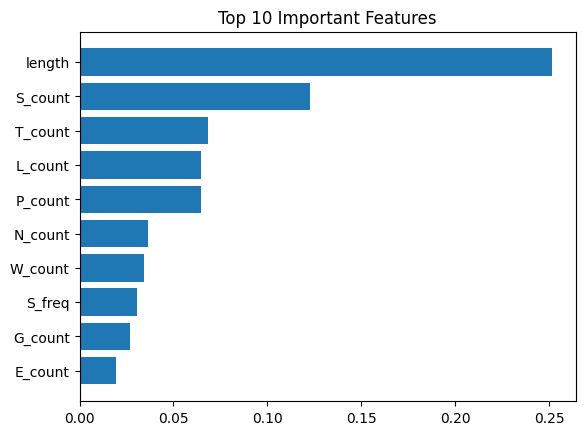

In [28]:
import matplotlib.pyplot as plt
import numpy as np

importances = model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure()
plt.title("Top 10 Important Features")
plt.barh(range(10), importances[indices])
plt.yticks(range(10), X.columns[indices])
plt.show()


In [32]:
sequence = "SNAASATETNTAPSADTQAPKPVNTVTSDVDCSVSAAWGLYKFNQKSNFSAEFEMPESVKAGTGFDALIKIKDISVSNDNLSGYKNAKLTKSSIRINVGKNVKLDGNQPGLSLSNGVLSINDHLKASLEGNSLRISAAPITVRLQALTEGTLTFIPEKTILTNTASVDGYTANTTCTTNADKPFATVKVDPADGLTITAPESASIKQDVQITATVPEKLNEKMDGKVQFFVNHIAAGDPVPVTEDNKASTSIIFDTSGSKTITARFIDAEGYNPAPDGETIIPVVTELDTKKPEDTDSYTGLINGSATSLLKPAKVMPGEKVSVSASLLPNKAPIRVYEIGINAPEDVKYIDGTGKTNYSSKLATTGSVFSSPGSGYYDPEWKNESKKPNESYRGFHSDTSYSVVDTSPQTVSAEFEIPKTLAPGIYMFQMGVYKYSNSLKDLVSIPETAFEIAGPDLPALPERKIKPQPEETPEVSDGSSTAKLVKSP"

In [33]:
def validate_sequence(seq):
    AMINO_ACIDS = set("ACDEFGHIKLMNPQRSTVWY")

    if len(seq) == 0:
        return "Invalid: Empty"

    if any(aa not in AMINO_ACIDS for aa in seq):
        return "Invalid: Contains non-standard amino acids"

    return "Valid Protein Sequence"

print("Length:", len(sequence))
print(validate_sequence(sequence))


Length: 489
Valid Protein Sequence


In [34]:
from collections import Counter
import numpy as np

AMINO_LIST = list("ACDEFGHIKLMNPQRSTVWY")

def extract_single_sequence_features(seq):
    length = len(seq)
    aa_counts = Counter(seq)

    features = []
    features.append(length)

    # Raw counts
    for aa in AMINO_LIST:
        features.append(aa_counts.get(aa, 0))

    # Frequency
    for aa in AMINO_LIST:
        features.append(aa_counts.get(aa, 0) / length if length > 0 else 0)

    return features

# Extract features
features = extract_single_sequence_features(sequence)

# Scale using trained scaler
features_scaled = scaler.transform([features])

# Predict
prediction = model.predict(features_scaled)[0]
probability = model.predict_proba(features_scaled)[0]

if prediction == 1:
    print("Predicted Class: Enzyme")
else:
    print("Predicted Class: Non-Enzyme")

print("Probability Enzyme:", probability[1])
print("Probability Non-Enzyme:", probability[0])



Predicted Class: Non-Enzyme
Probability Enzyme: 0.1425
Probability Non-Enzyme: 0.8575


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
